In [60]:
!pip install xarray netCDF4
! pip install matplotlib seaborn
! pip install cdsapi

In [61]:
import sys
!{sys.executable} -m pip install scikit-learn

In [62]:
!{sys.executable} -m pip install -r requirements.txt

  Using cached accelerate-1.10.1-py3-none-any.whl.metadata (19 kB)
  Using cached aiofiles-25.1.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiohttp-3.10.11-cp310-cp310-macosx_11_0_arm64.whl.metadata (7.7 kB)
  Using cached aiohttp_retry-2.8.3-py3-none-any.whl.metadata (8.9 kB)
  Using cached aioice-0.10.1-py3-none-any.whl.metadata (4.1 kB)
  Using cached aiortc-1.14.0-py3-none-any.whl.metadata (4.9 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached aiosqlite-0.21.0-py3-none-any.whl.metadata (4.3 kB)
  Using cached albucore-0.0.33-py3-none-any.whl.metadata (7.8 kB)
  Using cached albumentationsx-2.0.11-py3-none-any.whl.metadata (79 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached anthropic-0.49.0-py3-none-any.whl.metadata (24 kB)
  Using cached anyio-4.11.0-py3-none-any.whl.metadata (4.1 kB)
  Using cached anywidget-0.9.18-py3-none-a

In [63]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.metrics import (
    f1_score, precision_score, recall_score, roc_auc_score,
    average_precision_score
)
import os
import imageio.v2 as imageio
from datetime import datetime, timedelta
from scipy import ndimage
import zipfile
from collections import defaultdict
from tqdm.auto import tqdm

## ERA5-Land post-processed daily statistics from 1950 to present

## To request a file for MacOS: 
- go to your main directory in the terminal
- enter in the terminal: touch ~/.cdsapirc
- enter in the terminal: open ~/.cdsapirc
- copy paste your url and key in the .cdsapirc file 
- then run the cell below
- to not exceed the request size limit: choose four years and for each three months
- more info here: https://confluence.ecmwf.int/display/CKB/How+to+install+and+use+CDS+API+on+macOS

In [ ]:
# import cdsapi

# dataset = "derived-era5-land-daily-statistics"
# request = {
#     "year": "1990",
#     "month": ["06", "07", "08"],
#     "day": [
#         "01", "02", "03",
#         "04", "05", "06",
#         "07", "08", "09",
#         "10", "11", "12",
#         "13", "14", "15",
#         "16", "17", "18",
#         "19", "20", "21",
#         "22", "23", "24",
#         "25", "26", "27",
#         "28", "29", "30",
#         "31"
#     ],
#     "daily_statistic": "daily_mean",
#     "time_zone": "utc+00:00",
#     "frequency": "6_hourly",
#     "variable": ["volumetric_soil_water_layer_1"],
#     "area": [71, -25, 35, 45]
# }
# # start_year = request["year"][0]
# # end_year = request["year"][-1]
# client = cdsapi.Client()
# # output_file = f"era5_land_{start_year}_{end_year}.zip"
# output_file = f"era5_land_{request['year']}.zip"
# client.retrieve(dataset, request, output_file).download()

In [64]:
zip_dir = "/Users/malgorzatazdych/Documents/Master2/Thesis/Dataset/MasterThesis/era5_data/era5_land_downloads"
extract_dir = "/Users/malgorzatazdych/Documents/Master2/Thesis/Dataset/MasterThesis/era5_data/era5_land_extracted"
output_file = "/Users/malgorzatazdych/Documents/Master2/Thesis/Dataset/MasterThesis/era5_data/era5_land_merged_1990_2020.nc"

In [66]:
# for file in os.listdir(zip_dir):
#     if file.endswith(".zip"):
#         old_path = os.path.join(zip_dir, file)
#         new_path = os.path.join(zip_dir, file.replace(".zip", ".nc"))
#         os.rename(old_path, new_path)
        

In [7]:
files = sorted(
    os.path.join(zip_dir, f)
    for f in os.listdir(zip_dir)
    if f.endswith(".nc")
)

datasets = []
for f in files:
    # print("Loading", os.path.basename(f))
    ds = xr.open_dataset(f)

    rename_dict = {}
    if "latitude" in ds.coords:
        rename_dict["latitude"] = "lat"
    if "longitude" in ds.coords:
        rename_dict["longitude"] = "lon"
    if "valid_time" in ds.coords:
        rename_dict["valid_time"] = "time"
    if rename_dict:
        ds = ds.rename(rename_dict)

    if "lat" in ds.coords:
        ds = ds.sortby("lat")
    if "time" in ds.coords:
        ds = ds.sortby("time")

    datasets.append(ds)

ds_all = xr.concat(datasets, dim="time")
ds_all = ds_all.sortby("time")

# remove duplicate dates if any
_, idx = np.unique(ds_all["time"], return_index=True)
ds_all = ds_all.isel(time=np.sort(idx))

print(ds_all)
ds_all.to_netcdf("era5_land_1990_2020.nc")

Loading era5_land_1990_06_07.nc
Loading era5_land_1990_08_08.nc
Loading era5_land_1991_06_07.nc
Loading era5_land_1991_08_08.nc
Loading era5_land_1992_06_07.nc
Loading era5_land_1992_08_08.nc
Loading era5_land_1993_06_07.nc
Loading era5_land_1993_08_08.nc
Loading era5_land_1994_06_07.nc
Loading era5_land_1994_08_08.nc
Loading era5_land_1995_06_07.nc
Loading era5_land_1995_08_08.nc
Loading era5_land_1996_06_07.nc
Loading era5_land_1996_08_08.nc
Loading era5_land_1997_06_07.nc
Loading era5_land_1997_08_08.nc
Loading era5_land_1998_06_07.nc
Loading era5_land_1998_08_08.nc
Loading era5_land_1999_06_07.nc
Loading era5_land_1999_08_08.nc
Loading era5_land_2000_06_07.nc
Loading era5_land_2000_08_08.nc
Loading era5_land_2001_06_07.nc
Loading era5_land_2001_08_08.nc
Loading era5_land_2002_06_07.nc
Loading era5_land_2002_08_08.nc
Loading era5_land_2003_06_07.nc
Loading era5_land_2003_08_08.nc
Loading era5_land_2004_06_07.nc
Loading era5_land_2004_08_08.nc
Loading era5_land_2005_06_07.nc
Loading 

In [8]:
ds_land = xr.open_dataset("/Users/malgorzatazdych/Documents/Master2/Thesis/Dataset/MasterThesis/era5_data/era5_land_1990_2020.nc")
print(ds_land)
print(list(ds_land.data_vars))

<xarray.Dataset> Size: 3GB
Dimensions:  (time: 2852, lat: 361, lon: 701)
Coordinates:
    number   int64 8B ...
  * lat      (lat) float64 3kB 35.0 35.1 35.2 35.3 35.4 ... 70.7 70.8 70.9 71.0
  * lon      (lon) float64 6kB -25.0 -24.9 -24.8 -24.7 ... 44.7 44.8 44.9 45.0
  * time     (time) datetime64[ns] 23kB 1990-06-01 1990-06-02 ... 2020-08-31
Data variables:
    swvl1    (time, lat, lon) float32 3GB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-09T13:11 GRIB to CDM+CF via cfgrib-0.9.1...
['swvl1']


In [18]:
sw = ds_land["swvl1"]

print("Shape:", sw.shape)
print("Total values:", sw.size)
print("Missing values:", np.isnan(sw.values).sum())
print("Fraction missing:", np.isnan(sw.values).mean())

Shape: (2852, 361, 701)
Total values: 721729972
Missing values: 370916860
Fraction missing: 0.5139274720324348


In [19]:
missing_per_day = sw.isnull().sum(dim=("lat", "lon"))
frac_missing_per_day = missing_per_day / (sw.sizes["lat"] * sw.sizes["lon"])

print(frac_missing_per_day.max().item())
print(frac_missing_per_day.mean().item())

0.5139274720324348
0.5139274720324325


In [20]:
worst_days = frac_missing_per_day.sortby(frac_missing_per_day, ascending=False)
print(worst_days.isel(time=slice(0, 10)))

<xarray.DataArray 'swvl1' (time: 10)> Size: 80B
array([0.51392747, 0.51392747, 0.51392747, 0.51392747, 0.51392747,
       0.51392747, 0.51392747, 0.51392747, 0.51392747, 0.51392747])
Coordinates:
    number   int64 8B ...
  * time     (time) datetime64[ns] 80B 2020-08-31 2020-08-30 ... 2020-08-22


In [21]:
missing_per_pixel = sw.isnull().sum(dim="time")
frac_missing_per_pixel = missing_per_pixel / sw.sizes["time"]

print("Max fraction missing at any pixel:", frac_missing_per_pixel.max().item())
print("Mean fraction missing across pixels:", frac_missing_per_pixel.mean().item())

Max fraction missing at any pixel: 1.0
Mean fraction missing across pixels: 0.5139274720324348


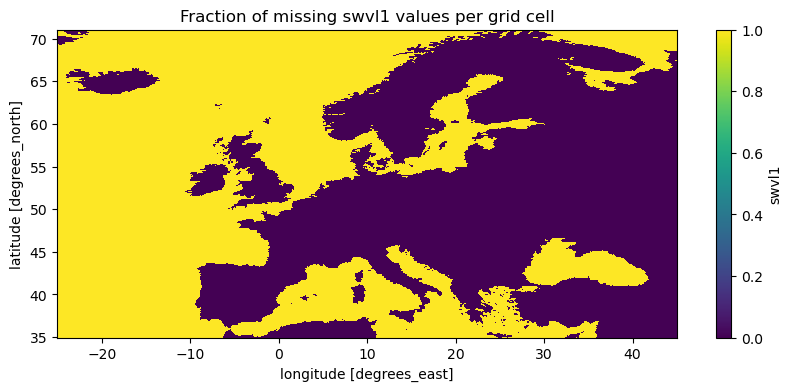

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
frac_missing_per_pixel.plot()
plt.title("Fraction of missing swvl1 values per grid cell")
plt.show()

## Land-sea masks

In [ ]:
land_mask = ~sw.isnull().all(dim="time") # True for sea, False for land 

In [16]:
sw_clean = sw.where(land_mask)

In [23]:
lsm = (~sw.isnull().all(dim="time")).astype(int)

In [28]:
print(lsm)

<xarray.DataArray 'swvl1' (lat: 361, lon: 701)> Size: 2MB
array([[0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(361, 701))
Coordinates:
    number   int64 8B ...
  * lat      (lat) float64 3kB 35.0 35.1 35.2 35.3 35.4 ... 70.7 70.8 70.9 71.0
  * lon      (lon) float64 6kB -25.0 -24.9 -24.8 -24.7 ... 44.7 44.8 44.9 45.0


In [29]:
# build new reusable dataset
era5_land_final = xr.Dataset(
    data_vars={
        "swvl1": sw,
        "land_mask": land_mask
    },
    coords={
        "time": ds_all["time"],
        "lat": ds_all["lat"],
        "lon": ds_all["lon"]
    }
)

In [30]:
era5_land_final.to_netcdf("era5_land_1990_2020.nc")

In [ ]:
era5_land = xr.open_dataset("era5_land_1990_2020.nc")
print(era5_land)


<xarray.Dataset> Size: 3GB
Dimensions:    (lat: 361, lon: 701, time: 2852)
Coordinates:
    number     int64 8B ...
  * lat        (lat) float64 3kB 35.0 35.1 35.2 35.3 ... 70.7 70.8 70.9 71.0
  * lon        (lon) float64 6kB -25.0 -24.9 -24.8 -24.7 ... 44.7 44.8 44.9 45.0
  * time       (time) datetime64[ns] 23kB 1990-06-01 1990-06-02 ... 2020-08-31
Data variables:
    swvl1      (time, lat, lon) float32 3GB ...
    land_mask  (lat, lon) bool 253kB ...


In [10]:
sw = era5_land["swvl1"]
mask = era5_land["land_mask"]

sw_clean = sw.where(mask == 1).fillna(0.0)

In [13]:
era5_land["swvl1"] = sw_clean
print(era5_land)

<xarray.Dataset> Size: 3GB
Dimensions:    (lat: 361, lon: 701, time: 2852)
Coordinates:
    number     int64 8B ...
  * lat        (lat) float64 3kB 35.0 35.1 35.2 35.3 ... 70.7 70.8 70.9 71.0
  * lon        (lon) float64 6kB -25.0 -24.9 -24.8 -24.7 ... 44.7 44.8 44.9 45.0
  * time       (time) datetime64[ns] 23kB 1990-06-01 1990-06-02 ... 2020-08-31
Data variables:
    swvl1      (time, lat, lon) float32 3GB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    land_mask  (lat, lon) bool 253kB False False False ... False False False


In [16]:
era5_land.to_netcdf("era5_land_two_var_1990_2020.nc")

In [17]:
era5_land = xr.open_dataset("era5_land_two_var_1990_2020.nc")
print(era5_land)

<xarray.Dataset> Size: 3GB
Dimensions:    (lat: 361, lon: 701, time: 2852)
Coordinates:
    number     int64 8B ...
  * lat        (lat) float64 3kB 35.0 35.1 35.2 35.3 ... 70.7 70.8 70.9 71.0
  * lon        (lon) float64 6kB -25.0 -24.9 -24.8 -24.7 ... 44.7 44.8 44.9 45.0
  * time       (time) datetime64[ns] 23kB 1990-06-01 1990-06-02 ... 2020-08-31
Data variables:
    swvl1      (time, lat, lon) float32 3GB ...
    land_mask  (lat, lon) bool 253kB ...


## ERA5 post-processed daily statistics on pressure levels from 1940 to present


In [67]:
zip_dir = "/Users/malgorzatazdych/Documents/Master2/Thesis/Dataset/MasterThesis/era5_data/era5_pressure"
extract_root = "/Users/malgorzatazdych/Documents/Master2/Thesis/Dataset/MasterThesis/era5_data/era5_extracted"
output_file = "/Users/malgorzatazdych/Documents/Master2/Thesis/Dataset/MasterThesis/era5_data/era5_pressure_1990_2020_merged.nc"

In [68]:
import os
import zipfile
import glob

zip_files = sorted(glob.glob(os.path.join(zip_dir, "pressure_*.zip")))

for zip_path in zip_files:
    year = os.path.basename(zip_path).replace("pressure_", "").replace(".zip", "")
    out_dir = os.path.join(zip_dir, year)

    os.makedirs(out_dir, exist_ok=True)

    print(f"Extracting {zip_path} -> {out_dir}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(out_dir)

## create one merged yearly file per year

In [69]:
import os
import glob
import xarray as xr
import pandas as pd


for year in range(1995, 2021):
    year_folder = os.path.join(zip_dir, str(year))

    if not os.path.isdir(year_folder):
        print(f"{year}: folder missing")
        continue

    nc_files = sorted(
        f for f in glob.glob(os.path.join(year_folder, "*.nc"))
        if not f.endswith("_merged.nc")
    )

    print(f"\n{year}: found {len(nc_files)} source files")
    for f in nc_files:
        print(" ", os.path.basename(f))

    if len(nc_files) == 0:
        print(f"{year}: no source files found")
        continue

    out_file = os.path.join(year_folder, f"era5_pressure_{year}_merged.nc")

    datasets = [xr.open_dataset(f) for f in nc_files]

    try:
        ds_year = xr.merge(datasets, compat="override")

        if "valid_time" in ds_year.coords:
            ds_year = ds_year.sortby("valid_time")

        vt = pd.to_datetime(ds_year["valid_time"].values)
        print(f"{year}: min={vt.min()}, max={vt.max()}, years={sorted(set(vt.year))}")

        ds_year.to_netcdf(out_file, mode="w")
        print(f"{year}: saved -> {out_file}")

    finally:
        for ds in datasets:
            ds.close()
        ds_year.close()


1995: found 3 source files
  geopotential_stream-oper_daily-mean.nc
  u_component_of_wind_0_daily-mean.nc
  v_component_of_wind_0_daily-mean.nc
1995: min=1995-06-01 00:00:00, max=1995-08-31 00:00:00, years=[1995]
1995: saved -> /Users/malgorzatazdych/Documents/Master2/Thesis/Dataset/MasterThesis/era5_data/era5_pressure/1995/era5_pressure_1995_merged.nc

1996: found 3 source files
  geopotential_stream-oper_daily-mean.nc
  u_component_of_wind_0_daily-mean.nc
  v_component_of_wind_0_daily-mean.nc
1996: min=1996-06-01 00:00:00, max=1996-08-31 00:00:00, years=[1996]
1996: saved -> /Users/malgorzatazdych/Documents/Master2/Thesis/Dataset/MasterThesis/era5_data/era5_pressure/1996/era5_pressure_1996_merged.nc

1997: found 3 source files
  geopotential_stream-oper_daily-mean.nc
  u_component_of_wind_0_daily-mean.nc
  v_component_of_wind_0_daily-mean.nc
1997: min=1997-06-01 00:00:00, max=1997-08-31 00:00:00, years=[1997]
1997: saved -> /Users/malgorzatazdych/Documents/Master2/Thesis/Dataset/Mas

### Check if the files are correctly stored

In [30]:
import os
import xarray as xr
import pandas as pd


for year in range(1995, 2021):
    f = os.path.join(zip_dir, str(year), f"era5_pressure_{year}_merged.nc")

    if not os.path.exists(f):
        print(f"{year}: merged file missing")
        continue

    ds = xr.open_dataset(f)
    vt = pd.to_datetime(ds["valid_time"].values)

    print(year, sorted(set(vt.year)), vt.min(), vt.max())
    ds.close()

1995 [1995] 1995-06-01 00:00:00 1995-08-31 00:00:00
1996 [1996] 1996-06-01 00:00:00 1996-08-31 00:00:00
1997 [1997] 1997-06-01 00:00:00 1997-08-31 00:00:00
1998 [1998] 1998-06-01 00:00:00 1998-08-31 00:00:00
1999 [1999] 1999-06-01 00:00:00 1999-08-31 00:00:00
2000 [2000] 2000-06-01 00:00:00 2000-08-31 00:00:00
2001 [2001] 2001-06-01 00:00:00 2001-08-31 00:00:00
2002 [2002] 2002-06-01 00:00:00 2002-08-31 00:00:00
2003 [2003] 2003-06-01 00:00:00 2003-08-31 00:00:00
2004 [2004] 2004-06-01 00:00:00 2004-08-31 00:00:00
2005 [2005] 2005-06-01 00:00:00 2005-08-31 00:00:00
2006 [2006] 2006-06-01 00:00:00 2006-08-31 00:00:00
2007 [2007] 2007-06-01 00:00:00 2007-08-31 00:00:00
2008 [2008] 2008-06-01 00:00:00 2008-08-31 00:00:00
2009 [2009] 2009-06-01 00:00:00 2009-08-31 00:00:00
2010 [2010] 2010-06-01 00:00:00 2010-08-31 00:00:00
2011 [2011] 2011-06-01 00:00:00 2011-08-31 00:00:00
2012 [2012] 2012-06-01 00:00:00 2012-08-31 00:00:00
2013 [2013] 2013-06-01 00:00:00 2013-08-31 00:00:00
2014 [2014] 

## reuse 1990-1994 dataset 

In [34]:
import xarray as xr
import os

base_file = "/Users/malgorzatazdych/Documents/Master2/Thesis/Dataset/MasterThesis/era5_data/era5_1990_1994_merged.nc"
fixed_file = "/Users/malgorzatazdych/Documents/Master2/Thesis/Dataset/MasterThesis/era5_data/era5_1990_1994_merged_fixed.nc"

ds = xr.open_dataset(base_file)

# rename time → valid_time
# ds = ds.rename({"valid_time": "time"})

# (optional but good) ensure it's sorted
ds = ds.sortby("valid_time")

ds.to_netcdf(fixed_file)
ds.close()

print("Saved fixed base file:", fixed_file)

ds.close()

Saved fixed base file: /Users/malgorzatazdych/Documents/Master2/Thesis/Dataset/MasterThesis/era5_data/era5_1990_1994_merged_fixed.nc


In [35]:
print(ds)

<xarray.Dataset> Size: 300MB
Dimensions:         (valid_time: 460, pressure_level: 1, lat: 145, lon: 281)
Coordinates:
    number          int64 8B ...
  * pressure_level  (pressure_level) float64 8B 500.0
  * lat             (lat) float64 1kB 35.0 35.25 35.5 35.75 ... 70.5 70.75 71.0
  * lon             (lon) float64 2kB -25.0 -24.75 -24.5 ... 44.5 44.75 45.0
  * valid_time      (valid_time) datetime64[ns] 4kB 1990-06-01 ... 1994-08-31
Data variables:
    v               (valid_time, pressure_level, lat, lon) float32 75MB ...
    u               (valid_time, pressure_level, lat, lon) float32 75MB ...
    z               (valid_time, pressure_level, lat, lon) float32 75MB ...
    z500            (valid_time, pressure_level, lat, lon) float32 75MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre f

In [36]:
import os
import xarray as xr
import pandas as pd
import numpy as np


base_file = "/Users/malgorzatazdych/Documents/Master2/Thesis/Dataset/MasterThesis/era5_data/era5_1990_1994_merged.nc"

all_files = [base_file] + [
    os.path.join(zip_dir, str(year), f"era5_pressure_{year}_merged.nc")
    for year in range(1995, 2021)
]

all_vt = []

for f in all_files:
    ds = xr.open_dataset(f)
    vt = pd.to_datetime(ds["valid_time"].values)
    all_vt.append(vt)
    print(os.path.basename(f), vt.min(), vt.max(), sorted(set(vt.year)))
    ds.close()

merged_vt = pd.DatetimeIndex(np.concatenate(all_vt))

print("First:", merged_vt.min())
print("Last:", merged_vt.max())
print("Years present:", sorted(set(merged_vt.year)))
print("Count:", len(merged_vt))
print(pd.Series(merged_vt.year).value_counts().sort_index())

era5_1990_1994_merged.nc 1990-06-01 00:00:00 1994-08-31 00:00:00 [1990, 1991, 1992, 1993, 1994]
era5_pressure_1995_merged.nc 1995-06-01 00:00:00 1995-08-31 00:00:00 [1995]
era5_pressure_1996_merged.nc 1996-06-01 00:00:00 1996-08-31 00:00:00 [1996]
era5_pressure_1997_merged.nc 1997-06-01 00:00:00 1997-08-31 00:00:00 [1997]
era5_pressure_1998_merged.nc 1998-06-01 00:00:00 1998-08-31 00:00:00 [1998]
era5_pressure_1999_merged.nc 1999-06-01 00:00:00 1999-08-31 00:00:00 [1999]
era5_pressure_2000_merged.nc 2000-06-01 00:00:00 2000-08-31 00:00:00 [2000]
era5_pressure_2001_merged.nc 2001-06-01 00:00:00 2001-08-31 00:00:00 [2001]
era5_pressure_2002_merged.nc 2002-06-01 00:00:00 2002-08-31 00:00:00 [2002]
era5_pressure_2003_merged.nc 2003-06-01 00:00:00 2003-08-31 00:00:00 [2003]
era5_pressure_2004_merged.nc 2004-06-01 00:00:00 2004-08-31 00:00:00 [2004]
era5_pressure_2005_merged.nc 2005-06-01 00:00:00 2005-08-31 00:00:00 [2005]
era5_pressure_2006_merged.nc 2006-06-01 00:00:00 2006-08-31 00:00:00

### Merge all the files 

In [71]:
import os
import pandas as pd
import numpy as np
import xarray as xr
from netCDF4 import Dataset, date2num

base_file = "/Users/malgorzatazdych/Documents/Master2/Thesis/Dataset/MasterThesis/era5_data/era5_1990_1994_merged.nc"
output_file = os.path.join(zip_dir, "era5_pressure_1990_2020_merged_correct.nc")

all_files = [base_file] + [
    os.path.join(zip_dir, str(year), f"era5_pressure_{year}_merged.nc")
    for year in range(1995, 2021)
]

# build correct valid_time first
all_vt = []
for f in all_files:
    ds = xr.open_dataset(f)
    all_vt.append(pd.to_datetime(ds["valid_time"].values))
    ds.close()

merged_vt = pd.DatetimeIndex(np.concatenate(all_vt))

# use first file as template
first = Dataset(all_files[0], "r")
out = Dataset(output_file, "w", format="NETCDF4")

for dim_name, dim in first.dimensions.items():
    if dim_name == "valid_time":
        out.createDimension(dim_name, None)
    else:
        out.createDimension(dim_name, len(dim))

COMMON_TIME_UNITS = "days since 1900-01-01 00:00:00"
COMMON_CALENDAR = "standard"

for var_name, var in first.variables.items():
    fill_value = getattr(var, "_FillValue", None)
    kwargs = {"fill_value": fill_value} if fill_value is not None else {}

    if var_name == "valid_time":
        out_var = out.createVariable(var_name, "f8", var.dimensions, **kwargs)
    else:
        out_var = out.createVariable(var_name, var.dtype, var.dimensions, **kwargs)

    for attr in var.ncattrs():
        if attr == "_FillValue":
            continue
        if var_name == "valid_time" and attr in ["units", "calendar"]:
            continue
        out_var.setncattr(attr, var.getncattr(attr))

out.variables["valid_time"].setncattr("units", COMMON_TIME_UNITS)
out.variables["valid_time"].setncattr("calendar", COMMON_CALENDAR)

for attr in first.ncattrs():
    out.setncattr(attr, first.getncattr(attr))

first.close()

# write full correct time axis once
out.variables["valid_time"][:] = date2num(
    merged_vt.to_pydatetime(),
    units=COMMON_TIME_UNITS,
    calendar=COMMON_CALENDAR
)

vt_start = 0

for i, f in enumerate(all_files):
    print("Appending", os.path.basename(f))
    ds = Dataset(f, "r")

    n_vt = len(ds.dimensions["valid_time"])
    vt_end = vt_start + n_vt

    if i == 0:
        for coord_name in ["pressure_level", "latitude", "longitude"]:
            if coord_name in ds.variables:
                out.variables[coord_name][:] = ds.variables[coord_name][:]

    for var_name, var in ds.variables.items():
        if var_name in ["valid_time", "pressure_level", "latitude", "longitude"]:
            continue
        out.variables[var_name][vt_start:vt_end, ...] = var[:]

    ds.close()
    out.sync()
    vt_start = vt_end

out.close()
print("Saved:", output_file)

Appending era5_1990_1994_merged.nc
Appending era5_pressure_1995_merged.nc
Appending era5_pressure_1996_merged.nc
Appending era5_pressure_1997_merged.nc
Appending era5_pressure_1998_merged.nc
Appending era5_pressure_1999_merged.nc
Appending era5_pressure_2000_merged.nc
Appending era5_pressure_2001_merged.nc
Appending era5_pressure_2002_merged.nc
Appending era5_pressure_2003_merged.nc
Appending era5_pressure_2004_merged.nc
Appending era5_pressure_2005_merged.nc
Appending era5_pressure_2006_merged.nc
Appending era5_pressure_2007_merged.nc
Appending era5_pressure_2008_merged.nc
Appending era5_pressure_2009_merged.nc
Appending era5_pressure_2010_merged.nc
Appending era5_pressure_2011_merged.nc
Appending era5_pressure_2012_merged.nc
Appending era5_pressure_2013_merged.nc
Appending era5_pressure_2014_merged.nc
Appending era5_pressure_2015_merged.nc
Appending era5_pressure_2016_merged.nc
Appending era5_pressure_2017_merged.nc
Appending era5_pressure_2018_merged.nc
Appending era5_pressure_2019_

### final check after merge

In [72]:
import xarray as xr
import pandas as pd
import os

file_path = os.path.join(zip_dir, "era5_pressure_1990_2020_merged_correct.nc")
ds_all = xr.open_dataset(file_path)

vt = pd.to_datetime(ds_all["valid_time"].values)
print("Years present:", sorted(set(vt.year)))
print("Count:", len(vt))
print(pd.Series(vt.year).value_counts().sort_index())

ds_all.close()

Years present: [1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]
Count: 2852
1990    92
1991    92
1992    92
1993    92
1994    92
1995    92
1996    92
1997    92
1998    92
1999    92
2000    92
2001    92
2002    92
2003    92
2004    92
2005    92
2006    92
2007    92
2008    92
2009    92
2010    92
2011    92
2012    92
2013    92
2014    92
2015    92
2016    92
2017    92
2018    92
2019    92
2020    92
Name: count, dtype: int64


In [73]:
ds_all = ds_all.rename({"valid_time": "time"})

In [74]:
ds_all = ds_all.sortby("time")
ds_all = ds_all.sortby("lat")
ds_all = ds_all.sortby("lon")

In [75]:
print(ds_all.dims)
print(ds_all.coords)

FrozenMappingWarningOnValuesAccess({'time': 2852, 'pressure_level': 1, 'lat': 145, 'lon': 281})
Coordinates:
    number          int64 8B ...
  * pressure_level  (pressure_level) float64 8B 500.0
  * lat             (lat) float64 1kB 35.0 35.25 35.5 35.75 ... 70.5 70.75 71.0
  * lon             (lon) float64 2kB -25.0 -24.75 -24.5 ... 44.5 44.75 45.0
  * time            (time) datetime64[ns] 23kB 1990-06-01 ... 2020-08-31


In [76]:
import pandas as pd

t = pd.to_datetime(ds_all["time"].values)
print("Unique times:", len(pd.unique(t)))
print("Total times:", len(t))

Unique times: 2852
Total times: 2852


In [80]:
ds_all = ds_all.drop_vars("z500")

In [81]:
for var in ds_all.data_vars:
    print(var, bool(ds_all[var].isnull().any()))

v False
u False
z False


In [82]:
for var in ds_all.data_vars:
    print(var, ds_all[var].isnull().sum().item())

v 0
u 0
z 0


In [83]:
print(ds_all)

<xarray.Dataset> Size: 1GB
Dimensions:         (time: 2852, pressure_level: 1, lat: 145, lon: 281)
Coordinates:
    number          int64 8B ...
  * pressure_level  (pressure_level) float64 8B 500.0
  * lat             (lat) float64 1kB 35.0 35.25 35.5 35.75 ... 70.5 70.75 71.0
  * lon             (lon) float64 2kB -25.0 -24.75 -24.5 ... 44.5 44.75 45.0
  * time            (time) datetime64[ns] 23kB 1990-06-01 ... 2020-08-31
Data variables:
    v               (time, pressure_level, lat, lon) float32 465MB -22.84 ......
    u               (time, pressure_level, lat, lon) float32 465MB 0.1436 ......
    z               (time, pressure_level, lat, lon) float32 465MB 5.674e+04 ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-08

In [86]:
ds_all.to_netcdf("/Users/malgorzatazdych/Documents/Master2/Thesis/Dataset/MasterThesis/era5_data/era5_pressure/era5_pressure_1990_2020_merged_clean.nc")